# Superstore Sales Analysis

## 1. Business Objective

This project analyzes the Superstore dataset to understand sales,
profitability, customer behavior, discounting, geographic performance,
and seasonal trends.

The analysis focuses on identifying factors associated with profitability
and translating the findings into actionable business recommendations.

## Key Questions

1. How do sales and profitability vary across categories and segments?
2. How does discounting relate to profitability?
3. Which customers contribute disproportionately to profit?
4. Which products and states generate significant losses?
5. How do sales and profitability change over time?

In [96]:
import numpy as np
import pandas as pd

In [97]:
df = pd.read_csv("Superstore Dataset.csv")

## 2. Dataset Overview & Data Preparation

The dataset contains 9,994 rows initially. I checked for missing values,
duplicate records, and date-format issues before beginning the analysis.

In [98]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2019-103800,2019-01-03,2019-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
3,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
4,CA-2019-141817,2019-01-05,2019-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [99]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [100]:
df.shape

(9994, 20)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Order Date     9994 non-null   datetime64[ns]
 2   Ship Date      9994 non-null   datetime64[ns]
 3   Ship Mode      9994 non-null   object        
 4   Customer ID    9994 non-null   object        
 5   Customer Name  9994 non-null   object        
 6   Segment        9994 non-null   object        
 7   Country        9994 non-null   object        
 8   City           9994 non-null   object        
 9   State          9994 non-null   object        
 10  Postal Code    9994 non-null   int64         
 11  Region         9994 non-null   object        
 12  Product ID     9994 non-null   object        
 13  Category       9994 non-null   object        
 14  Sub-Category   9994 non-null   object        
 15  Product Name   9994 n

In [102]:
df.isna().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [103]:
df.duplicated().sum()

np.int64(1)

In [104]:
df[df.duplicated(keep=False)]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
385,US-2019-150119,2019-04-23,2019-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
386,US-2019-150119,2019-04-23,2019-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


In [105]:
df = df.drop_duplicates()

Two duplicate records were identified and removed, leaving 9,992 records
for analysis.

## 3. Overall Business Performance

In [106]:
kpis = {
    "Total Sales": df['Sales'].sum(),
    "Total Profit": df['Profit'].sum(),
    "Profit Margin": df['Profit'].sum() / df['Sales'].sum() * 100,
    "Transactions": len(df),
    "Orders": df['Order ID'].nunique(),
    "Customers": df['Customer ID'].nunique()
}

kpis_df = pd.DataFrame(
    kpis.items(),
    columns=['KPI', 'Value']
)

kpis_df['Value'] = [
    f"${value:,.2f}" if kpi in ['Total Sales', 'Total Profit']
    else f"{value:.2f}%" if kpi == 'Profit Margin'
    else f"{int(value):,}"
    for kpi, value in zip(kpis_df['KPI'], kpis_df['Value'])
]

kpis_df

,KPI,Value
0,Total Sales,"$2,296,919.49"
1,Total Profit,"$286,409.08"
2,Profit Margin,12.47%
3,Transactions,"9,993"
4,Orders,"5,009"
5,Customers,793


## 4. Product & Category Analysis

### Category

In [107]:
category_summary = df.groupby('Category').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
)

In [108]:
category_summary['Profit Margin'] = round(category_summary['Profit'] / category_summary['Sales'] * 100,2)

In [109]:
category_summary

,Sales,Profit,Profit Margin
Category,,,
Furniture,741718.4233,18463.3316,2.49
Office Supplies,719047.0320,122490.8008,17.04
Technology,836154.0330,145454.9481,17.40


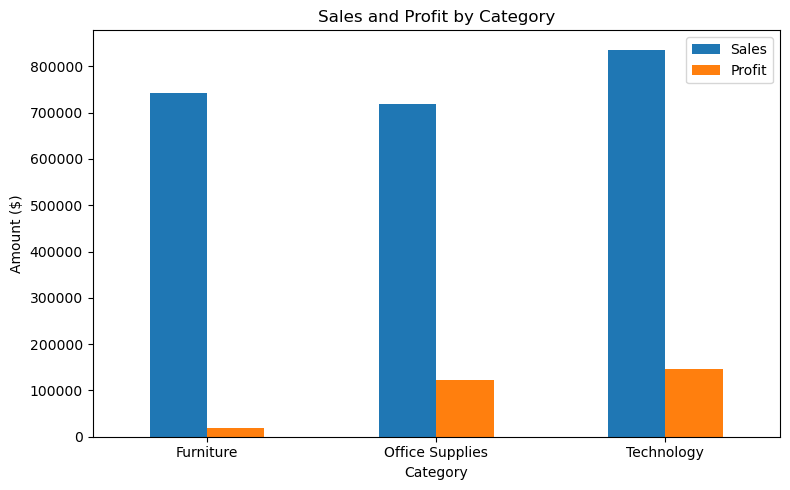

In [110]:
import matplotlib.pyplot as plt

category_summary[['Sales', 'Profit']].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Sales and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

### Sub-category

In [111]:
subcategory_summary = df.groupby('Sub-Category').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Avg_discount=('Discount','mean')
)

In [112]:
subcategory_summary['Profit Margin'] = round(subcategory_summary['Profit'] / subcategory_summary['Sales'] * 100, 2)

In [113]:
subcategory_summary.sort_values(by='Profit',ascending=False)                  

,Sales,Profit,Avg_discount,Profit Margin
Sub-Category,,,,
Copiers,149528.0300,55617.8249,0.161765,37.20
Phones,330007.0540,44515.7306,0.154556,13.49
Accessories,167380.3180,41936.6357,0.078452,25.05
Paper,78479.2060,34053.5693,0.074891,43.39
Binders,203412.7330,30221.7633,0.372292,14.86
Chairs,328167.7310,26602.2251,0.169968,8.11
Storage,223843.6080,21278.8264,0.074704,9.51
Appliances,107532.1610,18138.0054,0.166524,16.87
Furnishings,91705.1640,13059.1436,0.138349,14.24


### Product-Level Profitability

In [114]:
product_summary = df.groupby('Product Name').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
)

In [115]:
product_summary['Profit Margin'] = round(product_summary['Profit']/product_summary['Sales'] * 100,2)

In [116]:
product_summary.sort_values(by='Profit',ascending=False).head(10)

,Sales,Profit,Profit Margin
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,40.91
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,28.24
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,37.07
Canon PC1060 Personal Laser Copier,11619.834,4570.9347,39.34
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,22.29
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,49.00
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,26.00
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,39.46
Ibico EPK-21 Electric Binding System,15875.916,3345.2823,21.07


### Loss-making products

In [117]:
df[df['Product Name'] == 'Cubify CubeX 3D Printer Double Head Print']['Order ID'].nunique()

3

In [118]:
max_loss_prod = df[df['Product Name'] == 'Cubify CubeX 3D Printer Double Head Print'][['Order ID','Sales','Quantity','Discount','Profit']]

In [119]:
max_loss_prod

,Order ID,Sales,Quantity,Discount,Profit
3951,CA-2020-147830,1799.994,2,0.7,-2639.9912
6280,CA-2021-108196,4499.985,5,0.7,-6599.9780
7191,CA-2022-149881,4799.984,2,0.2,359.9988


## 5. Discount & Profitability Analysis

### Tables: Discount and Profitability
Tables was identified as a loss-making sub-category. This analysis examines how discount levels relate to its profitability.

In [120]:
df[df['Sub-Category'] == 'Tables']['Profit'].groupby(df['Discount']).sum()

Discount
0.00    13276.2997
0.20     -303.5580
0.30    -3402.3276
0.40   -16187.3968
0.45    -2493.1111
0.50    -8615.3873
Name: Profit, dtype: float64

In [121]:
df[df['Sub-Category'] == 'Tables']['Profit'].groupby(df['Discount']).mean()

Discount
0.00    184.393051
0.20     -4.275465
0.30    -63.006067
0.40   -215.831957
0.45   -226.646464
0.50   -239.316314
Name: Profit, dtype: float64

In [122]:
df[df['Sub-Category'] == 'Tables']['Sales'].groupby(df['Discount']).mean()

Discount
0.00    994.149444
0.20    639.862423
0.30    466.336111
0.40    608.192080
0.45    498.634000
0.50    379.861389
Name: Sales, dtype: float64

In [123]:
df[df['Sub-Category'] == 'Tables']['Quantity'].groupby(df['Discount']).mean()

Discount
0.00    4.305556
0.20    3.957746
0.30    3.333333
0.40    3.893333
0.45    4.090909
0.50    3.694444
Name: Quantity, dtype: float64

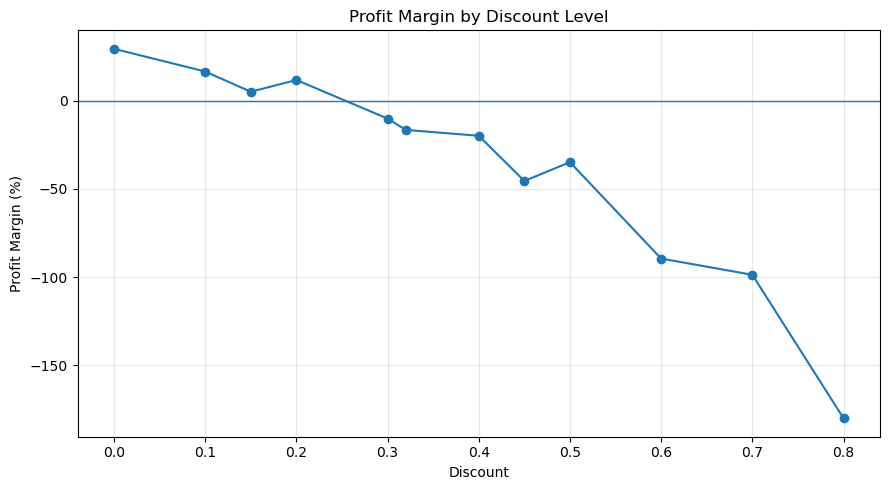

In [185]:
discount_analysis['Profit Margin'].plot(
    kind='line',
    marker='o',
    figsize=(9, 5)
)

plt.title('Profit Margin by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Profit Margin (%)')
plt.axhline(0, linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [125]:
product_summary = df.groupby('Product Name').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Transactions=('Order ID','count')
)

In [126]:
loss_making_products = product_summary[product_summary['Profit'] < 0].sort_values(by='Sales',ascending=False).head(10)

In [127]:
loss_making_products['Profit Margin'] = round(loss_making_products['Profit']/loss_making_products['Sales'] * 100,2)

In [128]:
loss_making_products

,Sales,Profit,Transactions,Profit Margin
Product Name,,,,
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800,-1811.0784,1,-8.00
GBC DocuBind P400 Electric Binding System,17965.0680,-1878.1662,6,-10.45
High Speed Automatic Electric Letter Opener,17030.3120,-262.0048,3,-1.54
Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4589.9730,4,-27.27
Martin Yale Chadless Opener Electric Letter Opener,16656.2000,-1299.1836,6,-7.80
"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",15610.9656,-669.5448,5,-4.29
Bretford Rectangular Conference Table Tops,12995.2915,-327.2331,12,-2.52
Cubify CubeX 3D Printer Double Head Print,11099.9630,-8879.9704,3,-80.00
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.6400,-2876.1156,5,-29.00


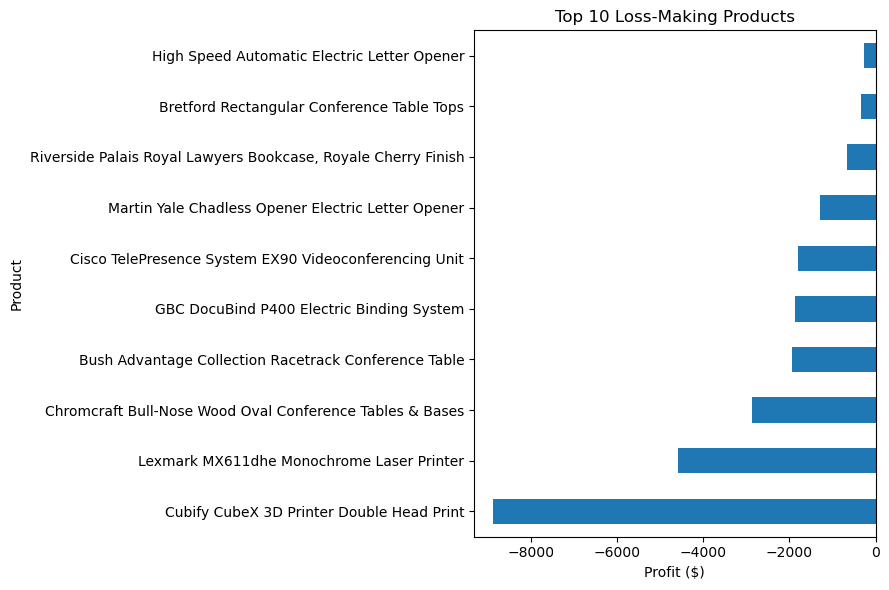

In [129]:
loss_making_products.sort_values('Profit').plot(
    y='Profit',
    kind='barh',
    figsize=(9, 6),
    legend=False
)

plt.title('Top 10 Loss-Making Products')
plt.xlabel('Profit ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [130]:
df[df['Product Name'] == '3.6 Cubic Foot Counter Height Office Refrigerator'][['Order ID','Sales','Quantity','Discount','Profit']]

,Order ID,Sales,Quantity,Discount,Profit
141,CA-2019-130421,176.772,3,0.8,-459.6072
5271,US-2021-141264,58.924,1,0.8,-153.2024
8134,CA-2022-156776,1473.100,5,0.0,412.4680
8531,CA-2022-115882,942.784,4,0.2,94.2784
9583,US-2022-147221,294.620,5,0.8,-766.0120


In [131]:
discount_analysis = df.groupby('Discount').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
)

In [132]:
discount_analysis['Profit Margin'] = round(discount_analysis['Profit']/discount_analysis['Sales'] * 100,2)

In [133]:
discount_analysis

,Sales,Profit,Profit Margin
Discount,,,
0.00,1.087908e+06,320987.6032,29.51
0.10,5.436935e+04,9029.1770,16.61
0.15,2.755852e+04,1418.9915,5.15
0.20,7.645944e+05,90337.3060,11.82
0.30,1.029453e+05,-10357.2186,-10.06
0.32,1.449346e+04,-2391.1377,-16.50
0.40,1.164178e+05,-23057.0504,-19.81
0.45,5.484974e+03,-2493.1111,-45.45
0.50,5.891854e+04,-20506.4281,-34.80


In [134]:
df[df['Product Name'] == '3D Systems Cube Printer, 2nd Generation, White'][['Sales','Quantity','Discount','Profit']]

,Sales,Quantity,Discount,Profit
1053,1299.990,2,0.5,-571.9956
9403,1039.992,1,0.2,103.9992


### Finding

High discounts were a recurring feature of material product losses. The loss-making products investigated showed major losses concentrated in transactions with very high discounts (50–80%), while lower-discount transactions for those products were profitable. This is consistent with the broader dataset-wide relationship between discounting and profitability.

## 6. Customer Analysis

### Segment Performance

In [135]:
segment_summary = df.groupby('Segment').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Customers=('Customer ID','nunique'),
    Orders=('Order ID','nunique'),
    Avg_Discount=('Discount','mean')
)

In [136]:
segment_summary['Profit Margin'] = round(segment_summary['Profit'] / segment_summary['Sales'] * 100,2)

In [137]:
segment_summary['Sales per Customer'] = round(segment_summary['Sales'] / segment_summary['Customers'],2)

In [138]:
segment_summary['Profit per Customer'] = round(segment_summary['Profit'] / segment_summary['Customers'],2)

In [139]:
segment_summary[['Sales','Profit','Profit Margin','Avg_Discount','Sales per Customer','Profit per Customer']]

,Sales,Profit,Profit Margin,Avg_Discount,Sales per Customer,Profit per Customer
Segment,,,,,,
Consumer,1.161401e+06,134119.2092,11.55,0.158141,2839.61,327.92
Corporate,7.061464e+05,91979.1340,13.03,0.158228,2992.15,389.74
Home Office,4.293718e+05,60310.7373,14.05,0.147043,2901.16,407.50


In [140]:
segment_category_summary = df.groupby(['Segment','Category']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Avg_discount=('Discount','mean')
)

In [141]:
segment_category_summary['Profit Margin'] = round(segment_category_summary['Profit']/segment_category_summary['Sales']*100,2)

In [142]:
segment_category_summary.sort_values(by='Profit',ascending=False)

Sales      Profit  Avg_discount  \
Segment     Category                                                 
Consumer    Technology       406399.8970  70797.8096      0.134385   
            Office Supplies  363952.1360  56330.3210      0.158746   
Corporate   Technology       246450.1190  44166.9980      0.131949   
            Office Supplies  230676.4620  40227.3202      0.160604   
Home Office Technology       183304.0170  30490.1405      0.127193   
            Office Supplies  124418.4340  25933.1596      0.147451   
Corporate   Furniture        229019.7858   7584.8158      0.174071   
Consumer    Furniture        391049.3120   6991.0786      0.176739   
Home Office Furniture        121649.3255   3887.4372      0.164626   

                             Profit Margin  
Segment     Category                        
Consumer    Technology               17.42  
            Office Supplies          15.48  
Corporate   Technology               17.92  
            Office Supplies          17.44  
Home Office Technology               16.63  
            Office Supplies          20.84  
Corporate   Furniture                 3.31  
Consumer    Furniture                 1.79  
Home Office Furniture                 3.20

### Customer Concentration

In [143]:
customer_sales = df.groupby('Customer ID')['Sales'].sum()

In [144]:
top_10_sales = customer_sales.sort_values(ascending=False).head(10).sum()

In [145]:
top_10_sales_share = round(top_10_sales/df['Sales'].sum() * 100,2)

In [146]:
top_10_sales_share

np.float64(6.7)

In [147]:
top_20pct_customers = customer_sales.sort_values(ascending=False).head(159).index

In [148]:
top_20pct_sales = customer_sales.loc[
    top_20pct_customers
].sum()

In [149]:
top_20pct_share = round(
    top_20pct_sales/df['Sales'].sum() * 100,
    2
)

In [150]:
top_20pct_share

np.float64(48.14)

In [151]:
customer_profit = df.groupby('Customer ID')['Profit'].sum()

In [152]:
top_customer_profit_share = round(customer_profit.loc[top_20pct_customers].sum()/df['Profit'].sum() * 100,2)

In [153]:
top_customer_profit_share

np.float64(59.51)

In [154]:
top_customer_margin = round(customer_profit.loc[top_20pct_customers].sum() / top_20pct_sales * 100,2)

In [155]:
top_customer_margin

np.float64(15.41)

In [156]:
remaining_customers = customer_sales.sort_values(ascending=False).iloc[159:].index

In [157]:
remaining_sales = customer_sales.loc[remaining_customers].sum()

In [158]:
remaining_profit = customer_profit.loc[remaining_customers].sum()

In [159]:
remaining_margin = round(remaining_profit/remaining_sales * 100,2)

In [160]:
remaining_margin

np.float64(9.74)

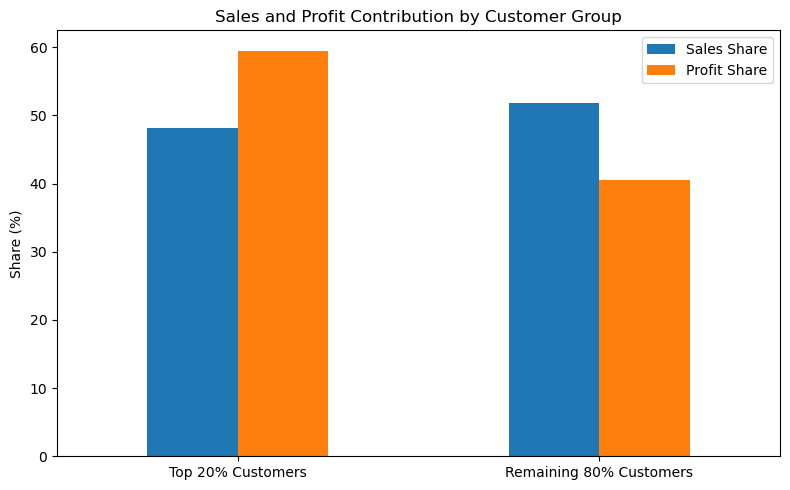

In [161]:
customer_concentration = pd.DataFrame({
    'Sales Share': [
        top_20pct_share,
        100 - top_20pct_share
    ],
    'Profit Share': [
        top_customer_profit_share,
        100 - top_customer_profit_share
    ]
}, index=['Top 20% Customers', 'Remaining 80% Customers'])

customer_concentration.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Sales and Profit Contribution by Customer Group')
plt.ylabel('Share (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

### Finding
The top 20% of customers by sales contribute a disproportionately large share of total profit, indicating that profitability is highly concentrated among high-value customers.

## 7. Geographic Analysis

In [162]:
state_summary = df.groupby('State').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
)

state_summary['Profit Margin'] = round(
    state_summary['Profit'] / state_summary['Sales'] * 100,
    2
)

state_summary['Average Order Value'] = round(
    state_summary['Sales'] / state_summary['Orders'],
    2
)

In [163]:
state_summary.sort_values(by='Sales',ascending=False).head(10)

,Sales,Profit,Orders,Profit Margin,Average Order Value
State,,,,,
California,457687.6315,76381.3871,1021,16.69,448.27
New York,310876.2710,74038.5486,562,23.82,553.16
Texas,170188.0458,-25729.3563,487,-15.12,349.46
Washington,138641.2700,33402.6517,256,24.09,541.57
Pennsylvania,116511.9140,-15559.9603,288,-13.35,404.56
Florida,89473.7080,-3399.3017,200,-3.80,447.37
Illinois,80166.1010,-12607.8870,276,-15.73,290.46
Ohio,77976.7640,-16959.3178,236,-21.75,330.41
Michigan,76269.6140,24463.1876,117,32.07,651.88


In [164]:
state_summary.sort_values(by='Profit Margin',ascending=False).head(10)

,Sales,Profit,Orders,Profit Margin,Average Order Value
State,,,,,
District of Columbia,2865.020,1059.5893,4,36.98,716.26
Delaware,27451.069,9977.3748,44,36.35,623.89
Minnesota,29863.150,10823.1874,44,36.24,678.71
Maine,1270.530,454.4862,3,35.77,423.51
Arkansas,11678.130,4008.6871,27,34.33,432.52
Indiana,53555.360,18382.9363,73,34.33,733.64
Georgia,49095.840,16250.0433,91,33.10,539.51
Montana,5589.352,1833.3285,8,32.80,698.67
Rhode Island,22627.956,7285.6293,25,32.20,905.12


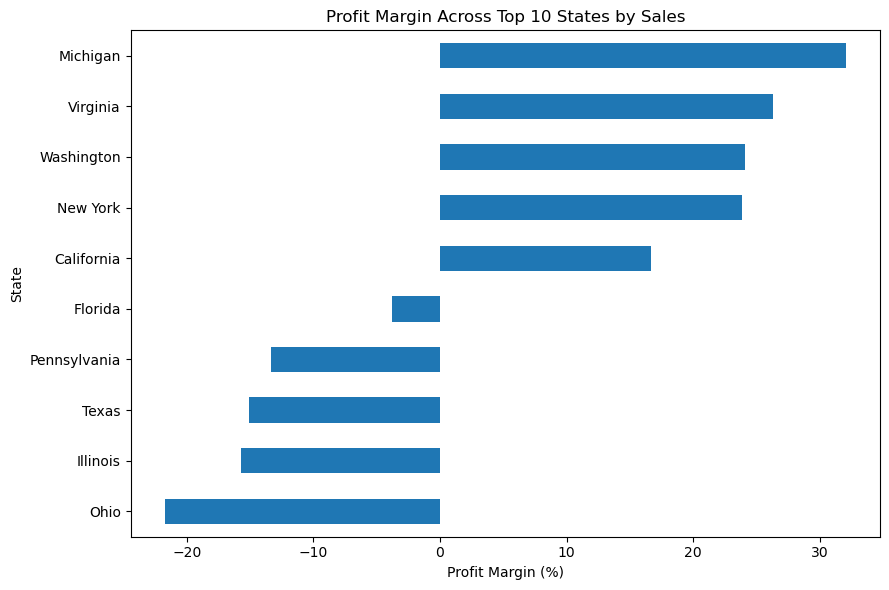

In [165]:
top_states = state_summary.sort_values(
    'Sales',
    ascending=False
).head(10)

top_states['Profit Margin'].sort_values().plot(
    kind='barh',
    figsize=(9, 6),
    legend=False
)

plt.title('Profit Margin Across Top 10 States by Sales')
plt.xlabel('Profit Margin (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Finding

Texas and Pennsylvania stand out as high-sales states with negative profit
margins. Their substantially higher average discounts compared with
profitable high-sales states suggest discounting is an important factor
to investigate.

In [166]:
state_discount = df.groupby('State')['Discount'].mean()

In [167]:
state_discount.loc[['Texas','Pennsylvania','California','New York']]

State
Texas           0.370193
Pennsylvania    0.328620
California      0.072764
New York        0.055319
Name: Discount, dtype: float64

In [168]:
df[df['State'].isin(['Texas','Pennsylvania'])].groupby(['State','Category'])['Discount'].mean()

State         Category       
Pennsylvania  Furniture          0.276800
              Office Supplies    0.342857
              Technology         0.342017
Texas         Furniture          0.422970
              Office Supplies    0.398675
              Technology         0.214525
Name: Discount, dtype: float64

In [169]:
state_summary['Profit Margin'] = round(state_summary['Profit']/state_summary['Sales'] * 100,2)

In [170]:
state_summary.sort_values(by='Profit Margin',ascending=False).head(10)

,Sales,Profit,Orders,Profit Margin,Average Order Value
State,,,,,
District of Columbia,2865.020,1059.5893,4,36.98,716.26
Delaware,27451.069,9977.3748,44,36.35,623.89
Minnesota,29863.150,10823.1874,44,36.24,678.71
Maine,1270.530,454.4862,3,35.77,423.51
Arkansas,11678.130,4008.6871,27,34.33,432.52
Indiana,53555.360,18382.9363,73,34.33,733.64
Georgia,49095.840,16250.0433,91,33.10,539.51
Montana,5589.352,1833.3285,8,32.80,698.67
Rhode Island,22627.956,7285.6293,25,32.20,905.12


## 8. Time & Seasonality Analysis

In [171]:
yearly_sales_profit = df.groupby(df['Order Date'].dt.year)[['Sales','Profit']].sum()

In [172]:
yearly_profit_margin = round(yearly_sales_profit['Profit'] / yearly_sales_profit['Sales'] * 100,2)

In [173]:
yearly_profit_margin

Order Date
2019    10.24
2020    13.10
2021    13.43
2022    12.74
dtype: float64

In [174]:
yearly_discount = df.groupby(
    df['Order Date'].dt.year
)['Discount'].mean()

In [175]:
yearly_discount

Order Date
2019    0.158213
2020    0.155609
2021    0.154743
2022    0.156467
Name: Discount, dtype: float64

In [176]:
yearly_sales_by_category = df.groupby([df['Order Date'].dt.year, 'Category'])['Sales'].sum()

In [177]:
yearly_sales_by_category

Order Date  Category       
2019        Furniture          156911.4811
            Office Supplies    151776.4120
            Technology         175278.2330
2020        Furniture          170518.2370
            Office Supplies    137233.4630
            Technology         162780.8090
2021        Furniture          198901.4360
            Office Supplies    183939.9820
            Technology         226364.1800
2022        Furniture          215387.2692
            Office Supplies    246097.1750
            Technology         271730.8110
Name: Sales, dtype: float64

In [178]:
yearly_categorywise_profit = df.groupby([df['Order Date'].dt.year,'Category'])['Profit'].sum()

In [179]:
yearly_categorywise_profit_margin = round(yearly_categorywise_profit/yearly_sales_by_category * 100,2)

In [180]:
yearly_categorywise_profit_margin

Order Date  Category       
2019        Furniture           3.49
            Office Supplies    14.89
            Technology         12.26
2020        Furniture           1.77
            Office Supplies    18.29
            Technology         20.58
2021        Furniture           3.50
            Office Supplies    19.06
            Technology         17.57
2022        Furniture           1.40
            Office Supplies    16.15
            Technology         18.65
dtype: float64

In [181]:
monthly_summary = df.groupby([df['Order Date'].dt.year,df['Order Date'].dt.month]).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
)

In [182]:
monthly_summary['Profit Margin'] = round(monthly_summary['Profit']/monthly_summary['Sales'] * 100,2)

In [183]:
monthly_summary

Sales      Profit  Profit Margin
Order Date Order Date                                        
2019       1            14236.8950   2450.1907          17.21
           2             4519.8920    862.3084          19.08
           3            55691.0090    498.7299           0.90
           4            28013.9730   3500.8940          12.50
           5            23648.2870   2738.7096          11.58
           6            34595.1276   4976.5244          14.39
           7            33946.3930   -841.4826          -2.48
           8            27909.4685   5318.1050          19.05
           9            81777.3508   8328.0994          10.18
           10           31453.3930   3448.2573          10.96
           11           78628.7167   9292.1269          11.82
           12           69545.6205   8983.5699          12.92
2020       1            18174.0756  -3281.0070         -18.05
           2            13593.5854   2826.5690          20.79
           3            37084.0776   9719.3796          26.21
           4            34646.1485   4253.7196          12.28
           5            30514.9445   4902.1242          16.06
           6            23963.0940   3035.0786          12.67
           7            29777.0210   3116.1375          10.46
           8            38254.2002   6280.2620          16.42
           9            63386.7680   7626.9201          12.03
           10           33352.6155   3569.7223          10.70
           11           79997.0515  12505.8409          15.63
           12           67788.9272   7063.8569          10.42
2021       1            18704.4610   2888.0395          15.44
           2            22816.8450   4941.3633          21.66
           3            51715.8750   3611.9680           6.98
           4            38750.0390   2977.8149           7.68
           5            56987.7280   8662.1464          15.20
           6            40344.5340   4750.3781          11.77
           7            39261.9630   4432.8779          11.29
           8            31115.3743   2062.0693           6.63
           9            73410.0249   9328.6576          12.71
           10           59687.7450  16243.1425          27.21
           11           79411.9658   4011.4075           5.05
           12           96999.0430  17885.3093          18.44
2022       1            43971.3740   7140.4391          16.24
           2            20301.1334   1613.8720           7.95
           3            58872.3528  14751.8915          25.06
           4            36521.5361    933.2900           2.56
           5            44261.1102   6342.5828          14.33
           6            52981.7257   8223.3357          15.52
           7            45264.4160   6952.6212          15.36
           8            63120.8880   9040.9557          14.32
           9            87866.6520  10991.5556          12.51
           10           77776.9232   9275.2755          11.93
           11          118447.8250   9690.1037           8.18
           12           83829.3188   8483.3468          10.12

## Key Findings

### 1. Discounting is strongly associated with lower profitability
Aggregate profit margin declined sharply as discount levels increased, turning negative at a 30% discount and reaching −180.03% at an 80% discount.

### 2. Profitability is highly concentrated among high-value customers
The top 20% of customers by sales generated 48.14% of total sales but 81.66% of total profit, with a 21.15% profit margin compared with 9.74% for the remaining 80%.

### 3. Several high-sales states are loss-making
Texas ($170.2K sales, −15.12% margin) and Pennsylvania (116.5K, −13.35%) generated substantial sales but negative profitability. Their average discounts (37.02% and 32.86%) were substantially higher than those of profitable high-sales states such as California and New York.

### 4. Consumer is the largest segment, but Home Office has the highest profit per customer
The loss-making products we investigated showed the same pattern: major losses were concentrated in transactions with very high discounts (50–80%), while lower-discount transactions for those products were profitable. This is consistent with the broader dataset-wide discount analysis.

### 5. Sales are seasonally stronger toward the end of the year
Sales grew substantially, with stronger sales toward the latter part of the year, but profitability did not improve consistently. Sales increased from approximately 484K in 2019 to 733K in 2022, while profit increased from 49.6K to \$93.4K. However, profit margin peaked at 13.43% in 2021 before declining to 12.74% in 2022, indicating that sales growth did not automatically translate into improving profitability.

## Business Recommendations

1. Review exceptionally high discounts, particularly 30%+ discounts.
2. Prioritize retention of high-value customers.
3. Investigate pricing and discounting practices in Texas and Pennsylvania.
4. Review materially loss-making products before considering discontinuation.
5. Monitor profitability during high-volume periods rather than relying
   on sales growth alone.